# Agent System Tests

Full end-to-end tests of the LangGraph agent graph.  
Uses a `MemorySaver` checkpointer so LangGraph manages state persistence.

Each test session is a **thread** (identified by `thread_id`). Calls on the same thread  
accumulate state; `graph.get_state()` lets you inspect what the agent stored.

**Section order**
| # | Section | What you learn |
|---|---------|---------------|
| 1 | Classifier | How the router decides which agent path to follow |
| 2 | MCP create_building (direct) | Low-level JSON-RPC call to Grasshopper — no AI |
| 3 | ReAct agent | Agent thinks → acts → observes in a loop (good for open-ended decisions) |
| 4 | Plan & Execute agent | Agent writes a fixed plan first, then runs each step (good for known multi-step tasks) |
| 5 | Full examples | One run per classification type, no forced routing |
| 6 | State history & memory | Checkpointing, multi-turn conversation |

**Prerequisites:**
- Rhino + Grasshopper running with the Swiftlet MCP server active (port 5001)
- `settings.py` + `.env.local` configured
- Run from the `src/` directory


In [4]:
## Setup — build graph with MemorySaver checkpointer
import os, sys, json, uuid, requests, importlib

# Ensure src/ is on the path
AGENT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if AGENT_ROOT not in sys.path:
    sys.path.insert(0, AGENT_ROOT)

# ── Force reload of all agent modules so edits take effect without kernel restart
# Order matters: state + config first, then nodes, then graph
import models.state
import config.design_rules
import nodes.building_design_node, nodes.classification_node
import nodes.search_node, nodes.planning_node, nodes.information_node
import graphs.main_graph

importlib.reload(models.state)
importlib.reload(config.design_rules)           # ← rules file must reload too
importlib.reload(nodes.building_design_node)
importlib.reload(nodes.classification_node)
importlib.reload(nodes.search_node)
importlib.reload(nodes.planning_node)
importlib.reload(nodes.information_node)
importlib.reload(graphs.main_graph)

from settings import LLM_PROVIDER, GEMINI_MODEL, MCP_GH_ENDPOINT
from langgraph.checkpoint.memory import MemorySaver
from graphs.main_graph import build_main_graph
from models.state import BoxState   # re-import after reload

memory = MemorySaver()
graph  = build_main_graph(checkpointer=memory)
print(f"Graph built ✓  (provider={LLM_PROVIDER}, model={GEMINI_MODEL})")

# Check MCP server (JSON-RPC 2.0 tools/list)
try:
    resp = requests.post(
        MCP_GH_ENDPOINT,
        json={"jsonrpc": "2.0", "id": 1, "method": "tools/list", "params": {}},
        headers={"Content-Type": "application/json"},
        timeout=3,
    )
    tools = resp.json().get("result", {}).get("tools", [])
    names = [t["name"] for t in tools]
    print(f"MCP Server : ✓  tools={names}")
except Exception as e:
    print(f"MCP Server : ✗  not reachable at {MCP_GH_ENDPOINT}  ({e})")

# ── Thread helpers ────────────────────────────────────────────────────────────
def new_thread(label: str = None) -> dict:
    tid = label or str(uuid.uuid4())[:8]
    print(f"thread_id : {tid}")
    return {"configurable": {"thread_id": tid}, "recursion_limit": 50}


# ── Per-node compact renderer ─────────────────────────────────────────────────
def _render_node(node_name: str, d: dict):
    """Print only the meaningful fields for each node — no redundant state dump.
    All workflow-specific data lives in d['context'] (the scratchpad)."""
    print(f"  ▶ [{node_name}]", end="")
    ctx = d.get("context") or {}   # workflow scratchpad

    if node_name == "classify_input":
        print(f"  →  request_type = {d.get('request_type', '?')}")
    elif node_name in ("thinking", "execute_action"):
        thought = str(ctx.get("thought") or "").replace("\n", " ")[:80]
        action  = ctx.get("action") or {}
        print(f"  thought: {thought}")
        if action:
            print(f"           action : {action}")
        else:
            print()
    elif node_name == "create_building_as_box":
        box = ctx.get("box") or {}
        print(f"  gfa={box.get('gfa')}  width={box.get('width')}  "
              f"n_floors={box.get('n_floors')}  depth={box.get('depth')}")
    elif node_name == "compliance_check":
        issues = ctx.get("issues") or []
        if issues:
            print(f"  {len(issues)} issue(s): {issues[0][:70]}{'…' if len(issues[0])>70 else ''}")
        else:
            print(f"  ✓ compliant")
    elif node_name == "is_compliant":
        itr = ctx.get("react_iteration", "?")
        print(f"  compliant = {ctx.get('compliant')}  (iteration {itr})")
    elif node_name in ("answer_with_search", "answer_without_search", "show_guide", "handle_unknown"):
        ans = str(d.get("answer") or "").replace("\n", " ")[:100]
        print(f"  {ans}{'…' if len(ans)==100 else ''}")
    elif node_name == "planner":
        plan = ctx.get("plan") or []
        print(f"  {len(plan)}-step plan")
    elif node_name == "execute_plan_step":
        print(f"  step {ctx.get('plan_step', '?')} done")
    elif node_name == "plan_summary":
        ans = str(d.get("answer") or "").replace("\n", " ")[:100]
        print(f"  {ans}{'…' if len(ans)==100 else ''}")
    else:
        print()


# ── run() — stream the graph and return (answer, result_dict) ─────────────────
def run(thread: dict, user_input: str, request_type: str = None, **kwargs) -> tuple:
    """Invoke the graph with a streaming update loop.

    Extra kwargs (e.g. site_area, n_floors, width, floor_height) are forwarded
    into state.request so building-design nodes can read them.
    Workflow-specific results are returned inside result['context'].
    """
    req = {"user_input": user_input, **kwargs}
    initial_state = BoxState(
        request=req,
        request_type=request_type,  # None → classifier decides
    )
    print(f"\n{'─'*72}")
    print(f"  INPUT : {user_input[:80]}{'…' if len(user_input)>80 else ''}")
    if kwargs:
        print(f"  PARAMS: {kwargs}")
    print(f"{'─'*72}")

    result = {}
    for update in graph.stream(initial_state, config=thread, stream_mode="updates"):
        for node_name, node_data in update.items():
            _render_node(node_name, node_data)
            result.update(node_data)

    answer = result.get("answer") or result.get("observation") or ""
    print(f"\n  ANSWER: {str(answer).replace(chr(10), ' ')[:120]}")
    return answer, result


# ── show_state() — pretty-print the latest checkpoint for a thread ────────────
def show_state(thread: dict):
    """Print a compact view of the persisted BoxState for the given thread."""
    snap = graph.get_state(thread)
    if not snap:
        print("  (no state found for this thread)")
        return None
    vals = snap.values
    ctx  = vals.get("context") or {}   # workflow scratchpad
    print(f"  request_type : {vals.get('request_type')}")
    print(f"  compliant    : {ctx.get('compliant')}")
    box = ctx.get("box") or {}
    if box:
        print(f"  box          : gfa={box.get('gfa')}  width={box.get('width')}  "
              f"n_floors={box.get('n_floors')}  depth={box.get('depth')}")
    issues = ctx.get("issues") or []
    print(f"  issues       : {issues if issues else '[]'}")
    history = vals.get("history") or []
    print(f"  history      : {len(history)} step(s)")
    return snap


Graph built ✓  (provider=gemini, model=gemini-2.5-flash-lite)
MCP Server : ✓  tools=['create_building', 'add_emergency_exits']


---
## 1 · Classifier — How the Router Decides

The **classifier** is the first node in the graph. It reads the user's message and assigns a `request_type`, which determines which agent branch runs next.

| `request_type` | Agent branch | Use when |
|---|---|---|
| `design_building` | ReAct loop | User wants a compliant building sized automatically |
| `plan` | Plan & Execute | User gives a numbered multi-step task |
| `use_tool` | Single tool call | User asks to run one specific Grasshopper tool |
| `show_guide` | Static answer | User asks what the design rules are |
| `general_question` | Q&A ± web search | User asks an architecture question |
| `unknown` | Polite refusal | Off-topic request |

Run the cell below to test the classifier on sample prompts directly — no full graph run needed.


In [5]:
# ── 1b: classification tests — call classify_input_fn directly (no graph run) ─
import importlib, nodes.classification_node, io
from contextlib import redirect_stdout
importlib.reload(nodes.classification_node)
from nodes.classification_node import classify_input_fn

CLASSIFIER_TESTS = [
    ("design_building",  "Design a 5-floor office building with a total area of 2000 m² that meets building code."),
    ("use_tool",         "Draw a cylinder at the origin with radius 5 and height 20."),
    ("show_guide",       "What are the design rules and constraints I need to follow for this project?"),
    ("general_question", "What is the difference between a load-bearing wall and a curtain wall?"),
    ("plan",             "1) Create a box at origin (10×8×4) using run_csharp_script. 2) Move it 15 units along X. 3) Capture the viewport."),
    ("unknown",          "What is the best pizza topping for a Friday night?"),
]

results = {}
for expected, prompt in CLASSIFIER_TESTS:
    state = BoxState(request={"user_input": prompt})
    with redirect_stdout(io.StringIO()):
        out = classify_input_fn(state)
    got = out.request_type
    ok  = got == expected
    results[expected] = {"got": got, "ok": ok}
    mark = "PASS ✓" if ok else "FAIL ✗"
    print(f"  {mark}  expected={expected:<20}  got={got:<20}  └─ {prompt[:60]}{'…' if len(prompt)>60 else ''}")

print()
passed = sum(1 for r in results.values() if r["ok"])
print(f"  {passed}/{len(results)} passed")


  PASS ✓  expected=design_building       got=design_building       └─ Design a 5-floor office building with a total area of 2000 m…
  PASS ✓  expected=use_tool              got=use_tool              └─ Draw a cylinder at the origin with radius 5 and height 20.
  PASS ✓  expected=show_guide            got=show_guide            └─ What are the design rules and constraints I need to follow f…
  PASS ✓  expected=general_question      got=general_question      └─ What is the difference between a load-bearing wall and a cur…
  PASS ✓  expected=plan                  got=plan                  └─ 1) Create a box at origin (10×8×4) using run_csharp_script. …
  PASS ✓  expected=unknown               got=unknown               └─ What is the best pizza topping for a Friday night?

  6/6 passed


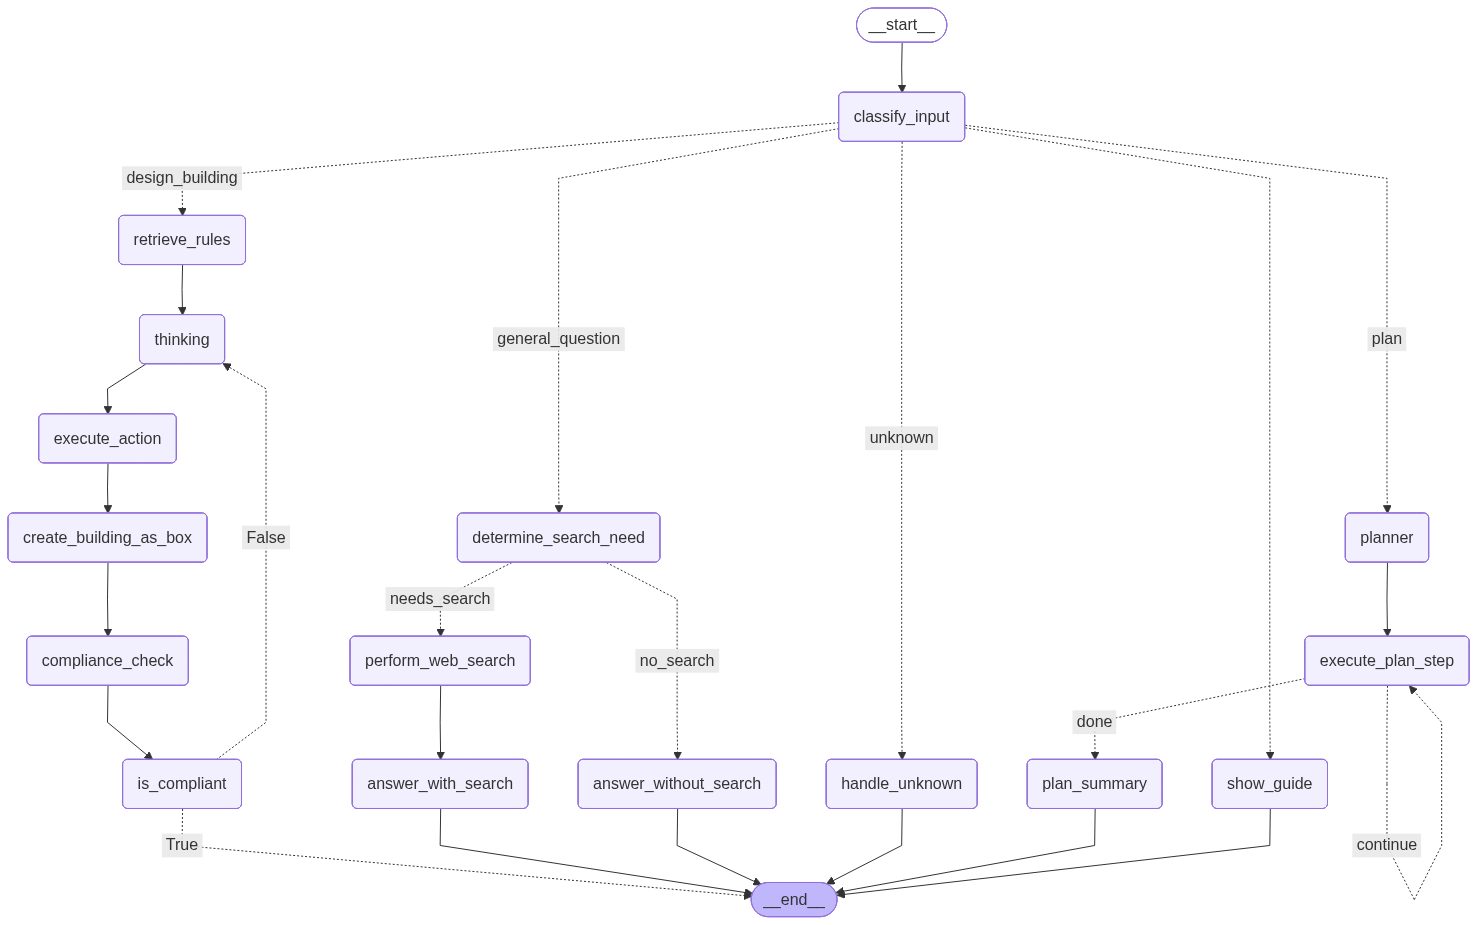

In [6]:

# ── Graph visualization — see how the router branches ─────────────────────────
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


---
## 2 · MCP Tool — Direct JSON-RPC Call (no AI)

Before adding any intelligence, let's understand the **raw tools** the agents will call.  
`create_building` and `add_emergency_exits` are Grasshopper components exposed over MCP.  
We call them directly via JSON-RPC 2.0 — no LangGraph, no LLM.

This confirms Rhino is running and shows exactly what each tool accepts and returns.


In [7]:
# ── 2a: list available MCP tools ─────────────────────────────────────────────
resp = requests.post(
    MCP_GH_ENDPOINT,
    json={"jsonrpc": "2.0", "id": 1, "method": "tools/list", "params": {}},
    headers={"Content-Type": "application/json"},
    timeout=5,
)
print(json.dumps(resp.json(), indent=2))


{
  "jsonrpc": "2.0",
  "id": 1,
  "result": {
    "tools": [
      {
        "name": "create_building",
        "description": "create a box-like building",
        "inputSchema": {
          "type": "object",
          "properties": {
            "site_area": {
              "type": "number",
              "description": "area of the building"
            },
            "width": {
              "type": "number",
              "description": "width of the building"
            },
            "number_of_floors": {
              "type": "integer",
              "description": "building 's number of floors"
            },
            "floor_height": {
              "type": "number",
              "description": "floor height"
            }
          },
          "required": [
            "site_area",
            "width",
            "number_of_floors",
            "floor_height"
          ]
        }
      },
      {
        "name": "add_emergency_exits",
        "description": "add_emer

In [8]:

# ── 2b: call create_building directly — inspect full JSON response + infer output schema
import ast

resp = requests.post(
    MCP_GH_ENDPOINT,
    json={
        "jsonrpc": "2.0",
        "id": 2,
        "method": "tools/call",
        "params": {
            "name": "create_building",
            "arguments": {
                "site_area": 150.0,     # footprint in m²
                "width": 10.0,
                "number_of_floors": 3,
                "floor_height": 4.0,
            },
        },
    },
    headers={"Content-Type": "application/json"},
    timeout=30,                     # GH may take a few seconds to compute geometry
)
data = resp.json()
print("── Full JSON-RPC response ───────────────────────────────────────")
print(json.dumps(data, indent=2))

content = data.get("result", {}).get("content", [])
print("\n── Inferred output schema ───────────────────────────────────────")
for item in content:
    if item.get("type") == "text":
        text = item["text"]
        try:
            parsed = json.loads(text)
        except json.JSONDecodeError:
            try:
                parsed = ast.literal_eval(text)
            except Exception:
                parsed = text
        if isinstance(parsed, dict):
            print(f"  type : object")
            for key, val in parsed.items():
                py_type = type(val).__name__ if val is not None else "null"
                print(f"    {key:<20} : {py_type}  (example: {val})")
        else:
            print(f"  type : {type(parsed).__name__}  value: {parsed}")


── Full JSON-RPC response ───────────────────────────────────────
{
  "jsonrpc": "2.0",
  "id": 2,
  "result": {
    "content": [
      {
        "type": "text",
        "text": "{\r\n  \"width\": 10.0,\r\n  \"depth\": 15.0,\r\n  \"height\": 4.0,\r\n  \"ratio_constraint\": 0.6666666666666666,\r\n  \"gross_floor_area\": 450\r\n}"
      }
    ]
  }
}

── Inferred output schema ───────────────────────────────────────
  type : object
    width                : float  (example: 10.0)
    depth                : float  (example: 15.0)
    height               : float  (example: 4.0)
    ratio_constraint     : float  (example: 0.6666666666666666)
    gross_floor_area     : int  (example: 450)


In [9]:

# ── 2c: call add_emergency_exits directly — trigger the GH component ──────────
resp_exits = requests.post(
    MCP_GH_ENDPOINT,
    json={
        "jsonrpc": "2.0",
        "id": 3,
        "method": "tools/call",
        "params": {
            "name": "add_emergency_exits",
            "arguments": {
                "add": True,
            },
        },
    },
    headers={"Content-Type": "application/json"},
    timeout=30,                     # GH may take a few seconds to respond
)
data_exits = resp_exits.json()
print("── Full JSON-RPC response ───────────────────────────────────────")
print(json.dumps(data_exits, indent=2))

content_exits = data_exits.get("result", {}).get("content", [])
print("\n── Parsed result ────────────────────────────────────────────────")
for item in content_exits:
    if item.get("type") == "text":
        text = item["text"]
        try:
            parsed = json.loads(text)
        except json.JSONDecodeError:
            try:
                parsed = ast.literal_eval(text)
            except Exception:
                parsed = text
        if isinstance(parsed, dict):
            for key, val in parsed.items():
                print(f"  {key:<20} : {val}")
        else:
            print(f"  {parsed}")


── Full JSON-RPC response ───────────────────────────────────────
{
  "jsonrpc": "2.0",
  "id": 3,
  "result": {
    "content": [
      {
        "type": "text",
        "text": "{\r\n  \"is_emergency_exits_added\": true\r\n}"
      }
    ]
  }
}

── Parsed result ────────────────────────────────────────────────
  is_emergency_exits_added : True


---
## 3 · ReAct Agent — Building Design with Compliance Loop

> **When to use ReAct:**  
> Use this when the task is **open-ended or adaptive** — the agent needs to *observe* the result of each action before deciding what to do next.  
> The agent thinks → acts → observes, repeating until it reaches a goal.

**Example here:** The agent picks a building width, calls Grasshopper to draw it, checks if it meets code, then *decides* whether to adjust and try again. It keeps looping until all rules pass — you never tell it how many iterations.

**Graph path:** `retrieve_rules → thinking → execute_action → create_building (MCP) → compliance_check → is_compliant` (loops back if not compliant)


In [10]:

# ── 3a: ReAct — maximize floors + react to initial 30m width ─────────────────
# Starting conditions (both deliberately off-spec to show the full agent loop):
#   width    = 30 m  → FAILS width_constraint  (max 20 m)
#   n_floors = 25    → GFA = 150×25 = 3750 m² → FAILS gfa_constraint (max 3000)
#                      also FAILS n_floors_constraint (max 4)
#
# Expected agent behaviour (branch priority: gfa/n_floors → width → depth/ratio → exits):
#   Loop 1  → gfa+n_floors fail  → adjust_floors to 4  (GFA=600, n_floors=4 ✓)
#   Loop 2  → width fails 30>20  → adjust_width to 20
#             but ratio = 20/7.5 = 2.67 (≤3 ✓), depth=7.5 ✓
#   Loop 3  → emergency_exit_constraint fails → add_emergency_exits
#   Loop 4  → all rules pass → done / EXIT
#
# site_area = footprint (m²);  GFA = site_area × n_floors must be ≤ 3000 m²
design_a = new_thread()   # random UUID — no stale checkpoint
answer_da, res_da = run(
    design_a,
    "Design a building with site area 150 m² that maximizes the number of floors "
    "while staying within the maximum GFA of 3000 m².",
    request_type="design_building",
    site_area=150,
    width=30,           # over the 20 m limit → agent must reduce
    n_floors=25,        # over the GFA limit and n_floors limit → agent must reduce to 4
    floor_height=3.5,
)


thread_id : b933412e

────────────────────────────────────────────────────────────────────────
  INPUT : Design a building with site area 150 m² that maximizes the number of floors whil…
  PARAMS: {'site_area': 150, 'width': 30, 'n_floors': 25, 'floor_height': 3.5}
────────────────────────────────────────────────────────────────────────
  ┊ pre-set: design_building
  ▶ [classify_input]  →  request_type = design_building
  ▶ [retrieve_rules]
  [thinking] LLM error (AttributeError): '_GeminiShim' object has no attribute 'invoke'
  ▶ [thinking]  thought: LLM unavailable — using rule-based fallback.

  ▶ [execute_action]  thought: LLM unavailable — using rule-based fallback.
           action : {'action': 'adjust_width', 'params': {'width': 30.0}}
  [create_building] → MCP site_area=150, width=30.0, n_floors=25, floor_height=3.5
  [create_building] ← [{'type': 'text', 'text': '{\r\n  "width": 30.0,\r\n  "depth": 5.0,\r\n  "height": 3.5,\r\n  "ratio_constraint": 6.0,\r\n  "gross_floor_area"

In [3]:
# ── 3b: inspect final state + full ReAct trace ───────────────────────────────
# The history shows every think→act→observe cycle the agent went through.
show_state(design_a)


  request_type : design_building
  compliant    : True
  box          : gfa=3750.0  width=26  n_floors=25  depth=5.769230769230769
  issues       : ['Failed gfa_constraint: Maximum gross floor area is 3000 sqm (GFA = site_area × n_floors)', 'Failed width_constraint: Maximum building width is 20m', 'Failed ratio_constraint: Width to depth ratio should be between 1:1 and 1:3', 'Failed emergency_exits_constraint: Building must have emergency exits if GFA > 500 sqm']
  history      : 40 step(s)


StateSnapshot(values={'request': {'user_input': 'Design a building with site area 150 m² that maximizes the number of floors while staying within the maximum GFA of 3000 m².', 'site_area': 150, 'width': 30, 'n_floors': 25, 'floor_height': 3.5}, 'request_type': 'design_building', 'answer': 'Could not fully satisfy all constraints after 8 iterations. Remaining issues: Failed gfa_constraint: Maximum gross floor area is 3000 sqm (GFA = site_area × n_floors), Failed width_constraint: Maximum building width is 20m, Failed ratio_constraint: Width to depth ratio should be between 1:1 and 1:3, Failed emergency_exits_constraint: Building must have emergency exits if GFA > 500 sqm. Best-effort design: {\'width\': 26, \'depth\': 5.769230769230769, \'site_area\': 150, \'gfa\': 3750.0, \'n_floors\': 25, \'floor_height\': 3.5, \'height\': 3.5, \'aspect_ratio\': 4.506666666666667, \'emergency_exits\': None, \'window_area\': None, \'mcp_result\': \'[{\\\'type\\\': \\\'text\\\', \\\'text\\\': \\\'{\\\\r

---
## 4 · Plan & Execute Agent

> **When to use Plan & Execute:**  
> Use this when the task is **multi-step and predictable** — you know all the steps upfront, and each step doesn't depend on the *outcome* of the previous one changing the plan.  
> The agent **writes a complete plan first**, then runs each step in sequence.

**vs. ReAct (§3):**
| | ReAct | Plan & Execute |
|---|---|---|
| **Planning** | One step at a time — decides the next action *after seeing the result* | Writes the full plan upfront, then executes |
| **Adaptability** | High — can change direction mid-run based on what it observes | Low — plan is fixed; won't replan on failure |
| **Best for** | Open-ended problems (e.g. "find the right width that satisfies all rules") | Known workflows (e.g. "create → transform → export") |
| **In this system** | `design_building` — iterates width until compliant | `plan` — runs a deterministic sequence of MCP tool calls |

**Graph path:** `planner → execute_plan_step (loop) → plan_summary`  
Each step result is stored in `BoxState.plan_results` and printed at the end.


In [ ]:
# ── 4a: plan — draw a box, then move it, then take a screenshot ───────────────
# The agent writes ALL steps first, then executes them one by one.
# Notice the plan is fixed upfront — the agent does NOT adapt mid-execution.
plan_simple = new_thread("plan-simple")
answer_ps, res_ps = run(
    plan_simple,
    "1) Use run_csharp_script to create a box at the origin that is 10 wide, 8 deep, "
    "and 5 tall using Brep.CreateFromBox. "
    "2) Use run_csharp_script to move the box 20 units along the X axis. "
    "3) Capture the Rhino viewport so we can see the result.",
    request_type="plan",
)


In [ ]:
# ── 4b: inspect final plan state ─────────────────────────────────────────────
show_state(plan_simple)


---
## 5 · Full Agent Examples — one per classification

No `request_type` is forced in any cell below.  
The classifier runs first and routes to the correct branch automatically.

| Cell | Expected route       | Scenario                                    |
|------|----------------------|---------------------------------------------|
| 5a   | `design_building`    | Whole-building sizing with code compliance  |
| 5b   | `show_guide`         | Ask for design rules                        |
| 5c   | `general_question`   | Architecture knowledge Q&A                  |
| 5d   | `plan`               | Multi-step MCP tool chain                   |
| 5e   | `unknown`            | Off-topic request                           |

In [ ]:

# ── 5a · design_building ──────────────────────────────────────────────────────
# Route: classify → retrieve_rules → thinking → execute_action
#        → create_building (MCP) → compliance_check → is_compliant (loop)
# site_area = footprint (m²);  GFA = site_area × n_floors must be ≤ 3000 m²
agent_design = new_thread("5a-design")
answer_design, res_design = run(
    agent_design,
    "Design a building with site area 300 m², 4 floors, and floor height 3.5 m "
    "that meets building code.",
    site_area=300,
    n_floors=4,
    floor_height=3.5,
)


In [ ]:
# ── 5b · show_guide ───────────────────────────────────────────────────────────
# Route: classify → show_guide → END
agent_guide = new_thread("5b-guide")
answer_guide, res_guide = run(
    agent_guide,
    "What are the design rules and constraints I need to follow for this project?",
)

In [ ]:
# ── 5c-1 · general_question — NO search needed ───────────────────────────────
# Route: classify → determine_search_need → answer_WITHOUT_search → END
# Fundamental architectural concept — the LLM answers from its training knowledge.
agent_qa = new_thread("5c-no-search")
answer_qa, res_qa = run(
    agent_qa,
    "What is the difference between a load-bearing wall and a curtain wall?",
)
print(f"  needs_search : {(res_qa.get('context') or {}).get('needs_search')}")


In [ ]:
# ── 5c-2 · general_question — search IS needed ─────────────────
# Route: classify → determine_search_need → answer_WITH_search → END
# Current-trends question — the LLM should recognise it needs a web search.
agent_qa2 = new_thread("5c-with-search")
answer_qa2, res_qa2 = run(
    agent_qa2,
    "What are the most prominent architecture and design trends emerging in 2025–2026, such as new materials, sustainable systems, or typological shifts?",
)
ctx_qa2 = res_qa2.get("context") or {}
print(f"  needs_search : {ctx_qa2.get('needs_search')}")
sr = ctx_qa2.get("search_results") or []
print(f"  search hits  : {len(sr)}")


In [ ]:
# ── 5c-2 · general_question — search IS needed ────────────────────────────────
# Route: classify → determine_search_need → answer_WITH_search → END
agent_qa2 = new_thread("5c-with-search")
answer_qa2, res_qa2 = run(
    agent_qa2,
    "What are the most prominent architecture and design trends emerging in 2025–2026, "
    "such as new materials, sustainable systems, or typological shifts?",
)

# ── Search diagnostics ────────────────────────────────────────────────────────
ctx_qa2  = res_qa2.get("context") or {}
needed   = ctx_qa2.get("needs_search")
sr       = ctx_qa2.get("search_results") or []

if needed is None:
    status = "⚠  needs_search not set (node may not have run)"
elif needed:
    status = f"✓  search ran  ({len(sr)} result{'s' if len(sr) != 1 else ''})"
else:
    status = "–  search skipped (LLM decided not needed)"

print(f"\n  Search status : {status}")

if sr:
    print(f"  {'#':<3}  {'Title / URL':<55}  Snippet")
    print("  " + "─" * 90)
    for idx, hit in enumerate(sr, 1):
        title   = str(hit.get("title") or hit.get("url") or "—")[:53]
        snippet = str(hit.get("snippet") or hit.get("content") or "—").replace("\n", " ")[:60]
        print(f"  {idx:<3}  {title:<55}  {snippet}{'…' if len(snippet)==60 else ''}")
elif needed:
    print("  (no results returned — check search tool / API key)")


In [ ]:
# ── 5e · unknown ──────────────────────────────────────────────────────────────
# Route: classify → handle_unknown → END
agent_unknown = new_thread("5e-unknown")
answer_unknown, res_unknown = run(
    agent_unknown,
    "What is the best pizza topping for a Friday night?",
)

In [ ]:
# ── 5f · summary ──────────────────────────────────────────────────────────────
sessions = [
    ("design_building",  res_design),
    ("show_guide",       res_guide),
    ("general_question", res_qa),
    ("plan",             res_plan),
    ("unknown",          res_unknown),
]
print(f"  {'Expected':<20}  {'Got':<20}  Answer preview")
print("  " + "─" * 70)
for label, r in sessions:
    got  = r.get("request_type", "?")
    ans  = str(r.get("answer") or "").replace("\n", " ")[:50]
    mark = "✓" if got == label else f"✗ got '{got}'"
    print(f"  {label:<20}  {mark:<20}  {ans}{'…' if len(ans) == 50 else ''}")

---
## 6 · Multi-turn Memory — continue from an existing session

`MemorySaver` persists the full `BoxState` checkpoint for every thread.  
Sending a **new message to the same `thread_id`** lets the agent pick up  
exactly where it left off — the `messages` list (reducer: `operator.add`)  
accumulates across turns, so the LLM sees the full conversation history.

**Demo**: reuse `agent_design` (1200 m², 4 floors, 3.5 m) from §5a  
and ask the agent to revise the building — *without* repeating any numbers.

In [ ]:
# ── 6b-1 · Inspect state before the follow-up ────────────────────────────────
# Shows what the agent already "knows" from the §5a run on this thread.
snap_before = show_state(agent_design)
print()
msgs = (snap_before.values.get("messages") or []) if snap_before else []
print(f"Messages stored in memory : {len(msgs)}")
for m in msgs[-4:]:          # print last 4 to keep output tidy
    role    = m.get("role", "?")
    preview = str(m.get("content", ""))[:120].replace("\n", " ")
    print(f"  [{role:9s}]  {preview}{'...' if len(str(m.get('content',''))) > 120 else ''}")

In [ ]:
# ── 6b-2 · Follow-up task — agent uses memory of the existing building ────────
# No area / n_floors / floor_height supplied — the agent must recall them
# from the checkpoint messages stored in MemorySaver.
answer_followup, res_followup = run(
    agent_design,                               # ← same thread as § 5a
    "I want to add 2 more floors to the building you just designed. "
    "Keep the same area and floor height as before, and re-check compliance.",
)

In [ ]:
# ── 6b-3 · Compare state before vs after the follow-up ───────────────────────
snap_after = show_state(agent_design)
print()
ctx_after  = (snap_after.values.get("context") or {}) if snap_after else {}
msgs_after = (snap_after.values.get("messages") or []) if snap_after else []
box_after  = ctx_after.get("box") or {}
print(f"Messages in memory now     : {len(msgs_after)}  (was {len(msgs)})")
print(f"Updated box params         : {box_after}")
